# Diffraction Grating Simulation

This notebook has two main runnable code cells:

1. **Monochromatic light**: explore how the diffraction pattern changes as the **number of slits** increases.
2. **Multiple wavelengths**: simulate a grating illuminated by several wavelengths at once and show where the different colors land on an extended screen.

Both sections use the standard grating model:

$$
I(\theta) \propto
\left(\frac{\sin \beta}{\beta}\right)^2
\left(\frac{\sin(N\alpha)}{\sin \alpha}\right)^2
$$

with

$$
\beta = \frac{\pi a \sin\theta}{\lambda}, \qquad
\alpha = \frac{\pi d \sin\theta}{\lambda}.
$$

The principal maxima satisfy the grating equation:

$$
d\sin\theta_m = m\lambda, \qquad m = 0, \pm1, \pm2, \ldots
$$

For a screen at distance $L$ (small-angle approximation), the fringe positions are:

$$
y_m \approx L\tan\theta_m \approx \frac{m\lambda L}{d}.
$$

where:
- $a$ is the slit width
- $d$ is the slit spacing
- $N$ is the number of slits
- $\lambda$ is the wavelength


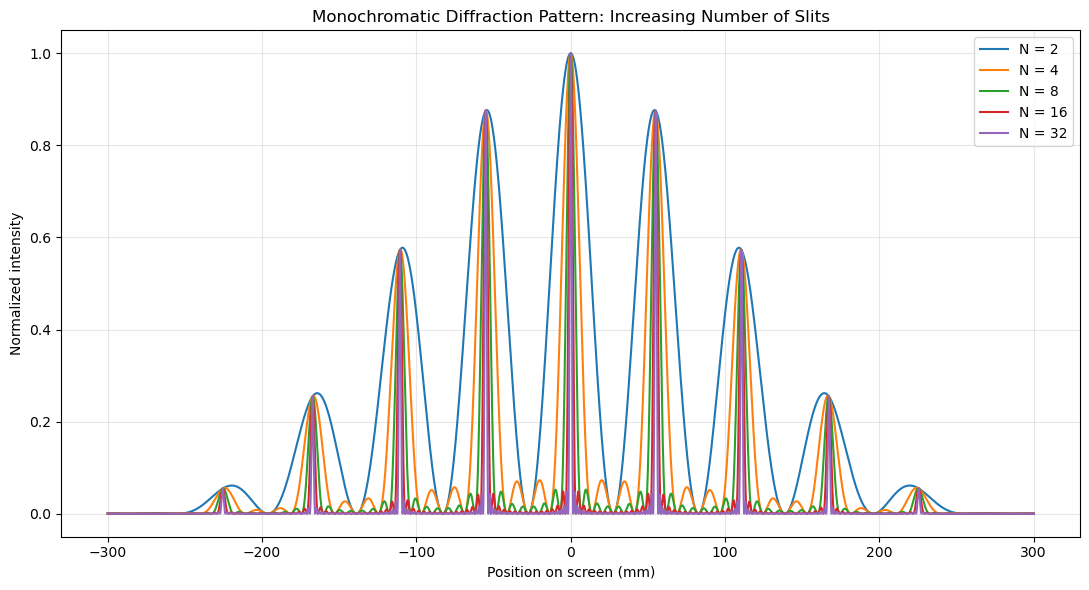

What to notice:
- As N increases, the bright grating peaks become narrower.
- The principal maxima become sharper and more intense relative to the background.
- The single-slit envelope stays the same because the slit width a is unchanged.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Cell 1: Monochromatic light and increasing number of slits
# ============================================================

# -----------------------------
# Parameters
# -----------------------------
wavelength = 550e-9       # 550 nm (green light)
slit_spacing = 10e-6      # grating spacing d (m)
slit_width = 2e-6         # slit width a (m)
screen_distance = 1.0     # distance to screen (m)

# Try different numbers of slits
slit_counts = [2, 4, 8, 16, 32]
#slit_counts = [2,3,4]

# Wider screen so multiple diffraction orders are visible
x = np.linspace(-0.30, 0.30, 12000)   # meters
theta = np.arctan(x / screen_distance)

def grating_intensity(theta, wavelength, a, d, N):
    beta = np.pi * a * np.sin(theta) / wavelength
    alpha = np.pi * d * np.sin(theta) / wavelength

    # Single-slit envelope
    single = np.ones_like(beta)
    mask_beta = np.abs(beta) > 1e-12
    single[mask_beta] = (np.sin(beta[mask_beta]) / beta[mask_beta])**2

    # Multi-slit interference
    interference = np.full_like(alpha, N**2, dtype=float)
    mask_alpha = np.abs(np.sin(alpha)) > 1e-12
    interference[mask_alpha] = (
        np.sin(N * alpha[mask_alpha]) / np.sin(alpha[mask_alpha])
    )**2

    return single * interference

plt.figure(figsize=(11, 6))

for N in slit_counts:
    I = grating_intensity(theta, wavelength, slit_width, slit_spacing, N)
    I /= I.max()
    plt.plot(x * 1000, I, lw=1.5, label=f'N = {N}')

plt.xlabel("Position on screen (mm)")
plt.ylabel("Normalized intensity")
plt.title("Monochromatic Diffraction Pattern: Increasing Number of Slits")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("What to notice:")
print("- As N increases, the bright grating peaks become narrower.")
print("- The principal maxima become sharper and more intense relative to the background.")
print("- The single-slit envelope stays the same because the slit width a is unchanged.")


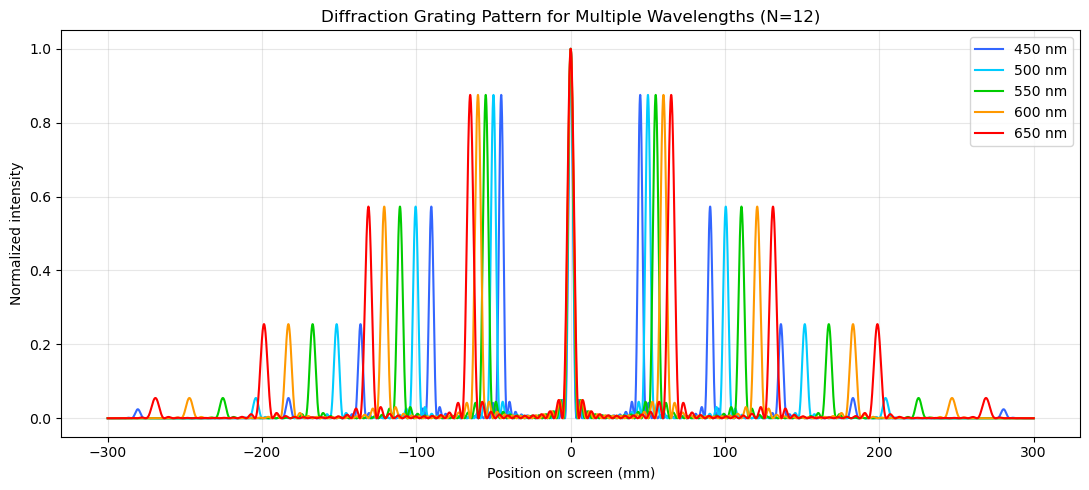

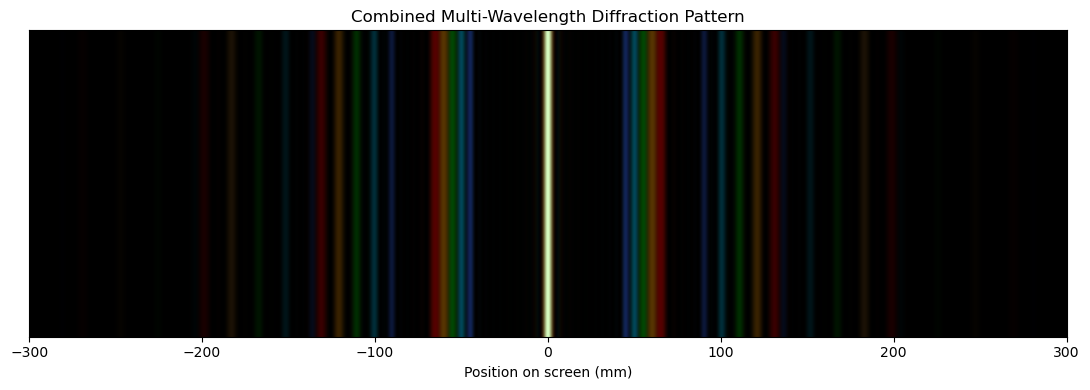

What to notice:
- Different wavelengths land at different positions on the screen.
- Longer wavelengths (redder light) appear farther from the center for a given order.
- The central maximum overlaps, but higher orders separate into colors.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Cell 2: Multiple wavelengths on the same grating
# ============================================================

# -----------------------------
# Grating parameters
# -----------------------------
slit_spacing = 10e-6      # grating spacing d (m)
slit_width   = 2e-6       # slit width a (m)
num_slits    = 12         # number of slits N
screen_distance = 1.0     # distance to screen (m)

# -----------------------------
# Wavelengths
# -----------------------------
wavelengths = np.array([
    450e-9,   # blue
    500e-9,   # cyan
    550e-9,   # green
    600e-9,   # orange
    650e-9    # red
])

labels = ['450 nm', '500 nm', '550 nm', '600 nm', '650 nm']

plot_colors = [
    (0.2, 0.4, 1.0),
    (0.0, 0.8, 1.0),
    (0.0, 0.8, 0.0),
    (1.0, 0.6, 0.0),
    (1.0, 0.0, 0.0)
]

# Extended screen so the separated orders are easier to see
x = np.linspace(-0.30, 0.30, 12000)   # meters
theta = np.arctan(x / screen_distance)

def grating_intensity(theta, wavelength, a, d, N):
    beta = np.pi * a * np.sin(theta) / wavelength
    alpha = np.pi * d * np.sin(theta) / wavelength

    single = np.ones_like(beta)
    mask_beta = np.abs(beta) > 1e-12
    single[mask_beta] = (np.sin(beta[mask_beta]) / beta[mask_beta])**2

    interference = np.full_like(alpha, N**2, dtype=float)
    mask_alpha = np.abs(np.sin(alpha)) > 1e-12
    interference[mask_alpha] = (
        np.sin(N * alpha[mask_alpha]) / np.sin(alpha[mask_alpha])
    )**2

    return single * interference

# -----------------------------
# Plot 1: intensity curves
# -----------------------------
plt.figure(figsize=(11, 5))
intensities = []

for wl, label, color in zip(wavelengths, labels, plot_colors):
    I = grating_intensity(theta, wl, slit_width, slit_spacing, num_slits)
    I /= I.max()
    intensities.append(I)
    plt.plot(x * 1000, I, label=label, color=color, lw=1.5)

plt.xlabel("Position on screen (mm)")
plt.ylabel("Normalized intensity")
plt.title(f"Diffraction Grating Pattern for Multiple Wavelengths (N={num_slits})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: combined color image
# -----------------------------
rgb_line = np.zeros((x.size, 3))

for I, color in zip(intensities, plot_colors):
    color = np.array(color)
    rgb_line += I[:, None] * color[None, :]

rgb_line /= rgb_line.max()
contrast = 1.0
rgb_line = np.clip((rgb_line - 0.5) * contrast + 0.5, 0, 1)

height = 250
rgb_image = np.tile(rgb_line[None, :, :], (height, 1, 1))

plt.figure(figsize=(11, 4))
plt.imshow(
    rgb_image,
    extent=[x[0] * 1000, x[-1] * 1000, -1, 1],
    aspect='auto',
    origin='lower'
)
plt.xlabel("Position on screen (mm)")
plt.yticks([])
plt.title("Combined Multi-Wavelength Diffraction Pattern")
plt.tight_layout()
plt.show()

print("What to notice:")
print("- Different wavelengths land at different positions on the screen.")
print("- Longer wavelengths (redder light) appear farther from the center for a given order.")
print("- The central maximum overlaps, but higher orders separate into colors.")
